# Candidate Screening for Quantum Materials

## Objective

Use the tuned Random Forest model to screen materials from the JARVIS-DFT
dataset based on predicted band gap.

The goal is to identify candidate materials whose predicted band gaps
fall within a selected target range for further investigation.

In [1]:
import numpy as np
import pandas as pd

from pathlib import Path

from jarvis.db.figshare import data
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

print("Imports successful.")

Imports successful.


In [2]:
data_path = Path("../data/enhanced_material_descriptors.csv")

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (93902, 26)
   num_elements  total_atoms  mean_atomic_number  min_atomic_number  \
0             4          4.0           24.500000               14.0   
1             2          7.0           13.714286                5.0   
2             3          4.0           32.000000                4.0   
3             2          2.0           51.000000               19.0   
4             2          3.0           30.333333               23.0   

   max_atomic_number  mean_atomic_mass  min_atomic_mass  max_atomic_mass  \
0               33.0         53.605025        28.085500          74.9216   
1               66.0         32.480857        10.811000         162.5000   
2               76.0         77.331091         9.012182         190.2300   
3               83.0        124.039350        39.098300         208.9804   
4               34.0         69.620500        50.941500          78.9600   

   mean_atomic_radius  min_atomic_radius  ...  electronegativity_difference  \
0         

In [3]:
feature_columns = [
    "num_elements",
    "total_atoms",
    "mean_atomic_number",
    "min_atomic_number",
    "max_atomic_number",
    "mean_atomic_mass",
    "min_atomic_mass",
    "max_atomic_mass",
    "mean_atomic_radius",
    "min_atomic_radius",
    "max_atomic_radius",
    "crys",
    "spg_number",
    "mean_electronegativity",
    "min_electronegativity",
    "max_electronegativity",
    "electronegativity_difference",
    "mean_ionization_energy",
    "mean_electron_affinity",
    "mean_s_valence",
    "mean_p_valence",
    "mean_d_valence",
    "mean_f_valence",
    "mean_period",
    "mean_group"
]

X_screen = df[feature_columns]

print("Screening features:", X_screen.shape)

Screening features: (93902, 25)


In [4]:
numeric_features = [
    "num_elements",
    "total_atoms",
    "mean_atomic_number",
    "min_atomic_number",
    "max_atomic_number",
    "mean_atomic_mass",
    "min_atomic_mass",
    "max_atomic_mass",
    "mean_atomic_radius",
    "min_atomic_radius",
    "max_atomic_radius",
    "mean_electronegativity",
    "min_electronegativity",
    "max_electronegativity",
    "electronegativity_difference",
    "mean_ionization_energy",
    "mean_electron_affinity",
    "mean_s_valence",
    "mean_p_valence",
    "mean_d_valence",
    "mean_f_valence",
    "mean_period",
    "mean_group"
]

categorical_features = [
    "crys",
    "spg_number"
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [5]:
dft_3d = data("dft_3d")
original_df = pd.DataFrame(dft_3d)

print("Original JARVIS dataset:", original_df.shape)

Obtaining 3D dataset 94k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699
Loading the zipfile...
Loading completed.
Original JARVIS dataset: (93902, 64)


In [6]:
df["jid"] = original_df["jid"].values
df["formula"] = original_df["formula"].values

print(
    df[["jid", "formula", "target_bandgap"]].head()
)

           jid   formula  target_bandgap
0  JVASP-90856  TiCuSiAs           0.000
1  JVASP-86097      DyB6           0.000
2  JVASP-64906   Be2OsRu           0.000
3  JVASP-98225       KBi           0.472
4     JVASP-10      VSe2           0.000


In [7]:
from sklearn.model_selection import train_test_split

X = df[feature_columns]
y = df["target_bandgap"]

y_class = (y > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print("Training:", X_train.shape)
print("Test:", X_test.shape)

Training: (75121, 25)
Test: (18781, 25)


In [8]:
screening_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

screening_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", screening_model)
])

print("Training screening model...")

screening_pipeline.fit(X_train, y_train)

print("Training complete.")

Training screening model...
Training complete.


In [9]:
all_predictions = screening_pipeline.predict(X)

df["predicted_bandgap"] = all_predictions

print(df["predicted_bandgap"].describe())

count    93902.000000
mean         0.581094
std          1.217817
min          0.000000
25%          0.000000
50%          0.010795
75%          0.464244
max         17.915443
Name: predicted_bandgap, dtype: float64


In [10]:
target_min = 1.0
target_max = 2.0

candidates = df[
    (df["predicted_bandgap"] >= target_min) &
    (df["predicted_bandgap"] <= target_max)
].copy()

print("Number of candidates:", len(candidates))

Number of candidates: 6861


In [11]:
target_gap = 1.5

candidates["distance_from_target"] = np.abs(
    candidates["predicted_bandgap"] - target_gap
)

candidates = candidates.sort_values(
    "distance_from_target"
)

candidates[
    [
        "jid",
        "formula",
        "target_bandgap",
        "predicted_bandgap",
        "distance_from_target"
    ]
].head(30)

,jid,formula,target_bandgap,predicted_bandgap,distance_from_target
23695,JVASP-7789,Rb2O,1.607,1.499873,0.000127
42294,JVASP-25631,NaNb2PS10,1.571,1.499755,0.000245
320,JVASP-98174,Na2LiAlP2,1.961,1.499655,0.000345
1817,JVASP-85570,Hg2ClO,1.798,1.499650,0.000350
55436,JVASP-121177,Al2N3O,0.000,1.500483,0.000483
55618,JVASP-121296,LiAuF4,1.797,1.499419,0.000581
84421,JVASP-164534,TlIn3S5,1.630,1.499385,0.000615
29658,JVASP-50450,ZrSeO,2.013,1.500695,0.000695
39201,JVASP-34401,Tb3CuSnS7,1.501,1.500765,0.000765
48518,JVASP-29264,Sb2Au3F18,0.178,1.499166,0.000834


In [12]:
candidates["prediction_error"] = np.abs(
    candidates["target_bandgap"] -
    candidates["predicted_bandgap"]
)

candidates[
    [
        "jid",
        "formula",
        "target_bandgap",
        "predicted_bandgap",
        "prediction_error"
    ]
].head(30)

,jid,formula,target_bandgap,predicted_bandgap,prediction_error
23695,JVASP-7789,Rb2O,1.607,1.499873,0.107127
42294,JVASP-25631,NaNb2PS10,1.571,1.499755,0.071245
320,JVASP-98174,Na2LiAlP2,1.961,1.499655,0.461345
1817,JVASP-85570,Hg2ClO,1.798,1.499650,0.298350
55436,JVASP-121177,Al2N3O,0.000,1.500483,1.500483
55618,JVASP-121296,LiAuF4,1.797,1.499419,0.297581
84421,JVASP-164534,TlIn3S5,1.630,1.499385,0.130615
29658,JVASP-50450,ZrSeO,2.013,1.500695,0.512305
39201,JVASP-34401,Tb3CuSnS7,1.501,1.500765,0.000235
48518,JVASP-29264,Sb2Au3F18,0.178,1.499166,1.321166


In [13]:
screening_error = candidates["prediction_error"]

print("Candidate screening statistics")
print("-" * 40)
print(f"Candidates: {len(candidates)}")
print(f"Mean error: {screening_error.mean():.4f} eV")
print(f"Median error: {screening_error.median():.4f} eV")
print(f"MAE: {screening_error.mean():.4f} eV")
print(f"Within 0.25 eV: {(screening_error <= 0.25).mean()*100:.2f}%")
print(f"Within 0.50 eV: {(screening_error <= 0.50).mean()*100:.2f}%")

Candidate screening statistics
----------------------------------------
Candidates: 6861
Mean error: 0.3868 eV
Median error: 0.2092 eV
MAE: 0.3868 eV
Within 0.25 eV: 55.46%
Within 0.50 eV: 75.60%


In [14]:
validated_candidates = candidates[
    candidates["prediction_error"] <= 0.25
].copy()

validated_candidates = validated_candidates.sort_values(
    "distance_from_target"
)

print("Validated candidates:", len(validated_candidates))

validated_candidates[
    [
        "jid",
        "formula",
        "target_bandgap",
        "predicted_bandgap",
        "prediction_error"
    ]
].head(30)

Validated candidates: 3805


,jid,formula,target_bandgap,predicted_bandgap,prediction_error
23695,JVASP-7789,Rb2O,1.607,1.499873,0.107127
42294,JVASP-25631,NaNb2PS10,1.571,1.499755,0.071245
84421,JVASP-164534,TlIn3S5,1.630,1.499385,0.130615
39201,JVASP-34401,Tb3CuSnS7,1.501,1.500765,0.000235
24100,JVASP-8004,CaC2,1.444,1.500915,0.056915
3347,JVASP-88221,P4S3I2,1.608,1.501060,0.106940
28340,JVASP-9159,Ga2S3,1.677,1.498845,0.178155
7286,JVASP-3684,K2PtCl6,1.646,1.501380,0.144620
25607,JVASP-48641,Li3Mn5OF11,1.557,1.498364,0.058636
69709,JVASP-146933,Li3Mn5OF11,1.358,1.498364,0.140364


In [16]:
# Recreate the train/test split

from sklearn.model_selection import train_test_split

X = df[feature_columns]
y = df["target_bandgap"]

y_class = (y > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print("Training:", X_train.shape)
print("Test:", X_test.shape)

Training: (75121, 25)
Test: (18781, 25)


In [19]:
screening_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

screening_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", screening_model)
])

print("Training final screening model...")

screening_pipeline.fit(X_train, y_train)

print("Training complete.")

Training final screening model...
Training complete.


In [20]:
test_predictions = screening_pipeline.predict(X_test)

print("Predictions generated:", len(test_predictions))

Predictions generated: 18781


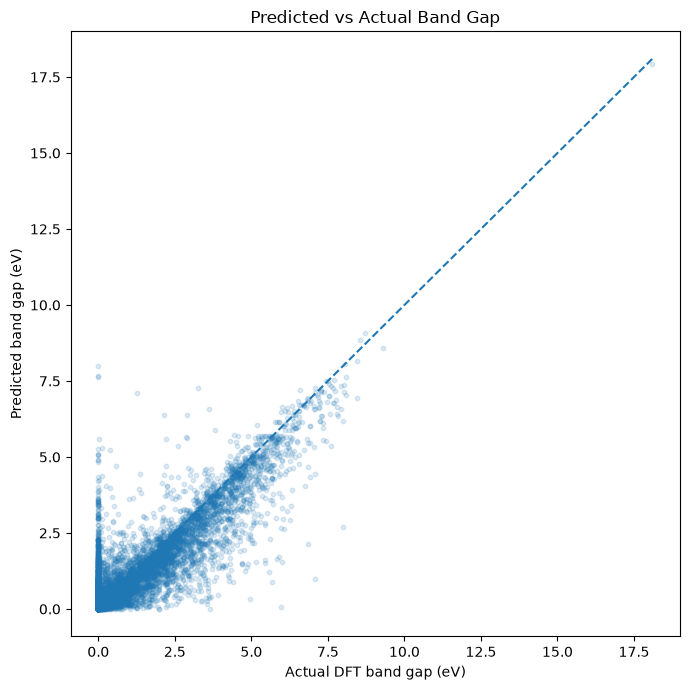

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    test_predictions,
    alpha=0.15,
    s=10
)

min_val = min(y_test.min(), test_predictions.min())
max_val = max(y_test.max(), test_predictions.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual DFT band gap (eV)")
plt.ylabel("Predicted band gap (eV)")
plt.title("Predicted vs Actual Band Gap")

plt.tight_layout()
plt.show()

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# Prepare features and target
X = df[feature_columns]
y = df["target_bandgap"]

# Same stratification used in Notebook 03
y_class = (y > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 75121
Test samples: 18781


In [23]:
screening_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

screening_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", screening_model)
])

screening_pipeline.fit(X_train, y_train)

print("Final screening model trained successfully.")

Final screening model trained successfully.


In [24]:
test_predictions = screening_pipeline.predict(X_test)

print("Predictions generated:", len(test_predictions))

Predictions generated: 18781


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

final_mae = mean_absolute_error(y_test, test_predictions)
final_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
final_r2 = r2_score(y_test, test_predictions)

print(f"MAE  : {final_mae:.4f} eV")
print(f"RMSE : {final_rmse:.4f} eV")
print(f"R²   : {final_r2:.4f}")

MAE  : 0.2381 eV
RMSE : 0.5559 eV
R²   : 0.8195


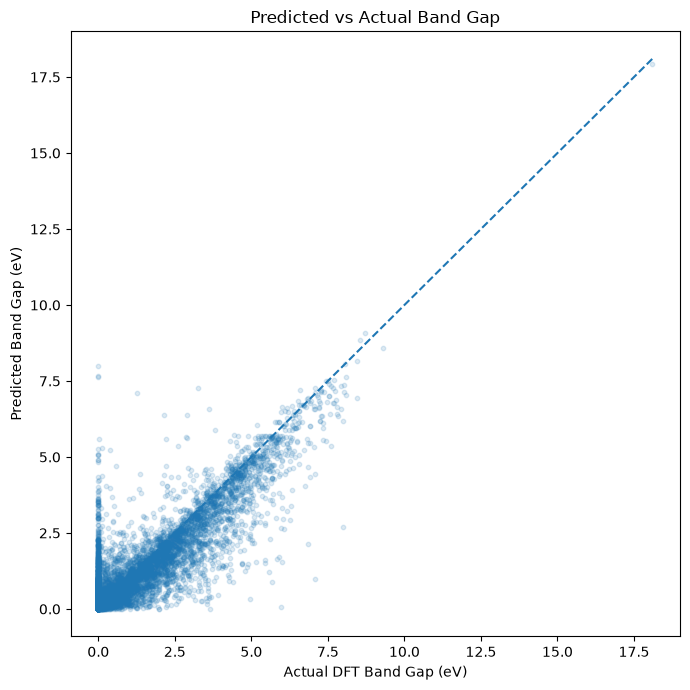

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    test_predictions,
    alpha=0.15,
    s=10
)

min_val = min(y_test.min(), test_predictions.min())
max_val = max(y_test.max(), test_predictions.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual DFT Band Gap (eV)")
plt.ylabel("Predicted Band Gap (eV)")
plt.title("Predicted vs Actual Band Gap")

plt.tight_layout()
plt.show()

Training samples: 75121
Test samples: 18781

Training final model...
Final screening model trained successfully.

Predictions generated: 18781

Final Model Performance
----------------------------------------
MAE  : 0.2381 eV
RMSE : 0.5559 eV
R²   : 0.8195


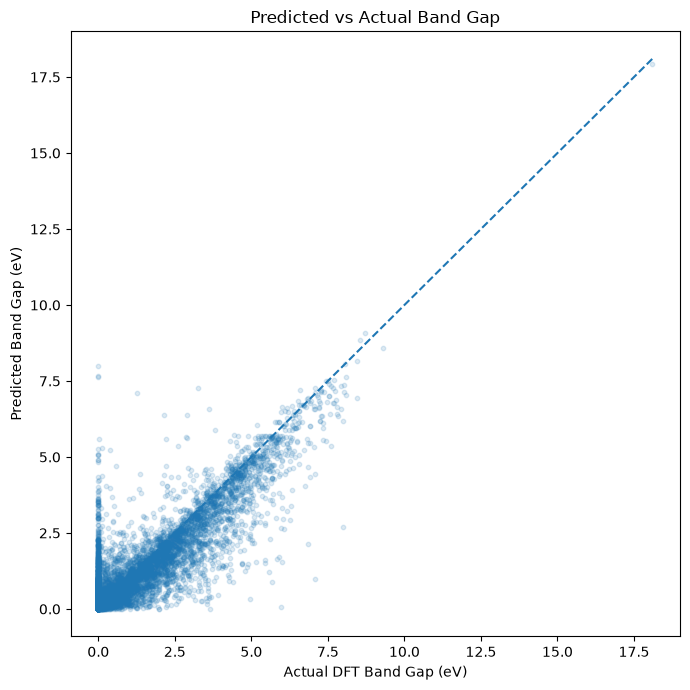

In [27]:
# ============================================================
# 04 — Recreate test split + train final model + predictions
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Prepare X and y
# ------------------------------------------------------------

X = df[feature_columns]
y = df["target_bandgap"]

# Same stratification used in Notebook 03
y_class = (y > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))


# ------------------------------------------------------------
# 2. Final tuned Random Forest
# ------------------------------------------------------------

screening_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

screening_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", screening_model)
])

print("\nTraining final model...")
screening_pipeline.fit(X_train, y_train)

print("Final screening model trained successfully.")


# ------------------------------------------------------------
# 3. Generate predictions
# ------------------------------------------------------------

test_predictions = screening_pipeline.predict(X_test)

print("\nPredictions generated:", len(test_predictions))


# ------------------------------------------------------------
# 4. Evaluate
# ------------------------------------------------------------

final_mae = mean_absolute_error(y_test, test_predictions)
final_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
final_r2 = r2_score(y_test, test_predictions)

print("\nFinal Model Performance")
print("-" * 40)
print(f"MAE  : {final_mae:.4f} eV")
print(f"RMSE : {final_rmse:.4f} eV")
print(f"R²   : {final_r2:.4f}")


# ------------------------------------------------------------
# 5. Predicted vs Actual plot
# ------------------------------------------------------------

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    test_predictions,
    alpha=0.15,
    s=10
)

min_val = min(y_test.min(), test_predictions.min())
max_val = max(y_test.max(), test_predictions.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual DFT Band Gap (eV)")
plt.ylabel("Predicted Band Gap (eV)")
plt.title("Predicted vs Actual Band Gap")

plt.tight_layout()
plt.show()

### Create predictions for all JARVIS materials

In [28]:
# ============================================================
# STEP 1 — Predict band gaps for all materials
# ============================================================

all_X = df[feature_columns]

all_predictions = screening_pipeline.predict(all_X)

df_screened = df.copy()
df_screened["predicted_bandgap"] = all_predictions

print("Predictions generated:", len(df_screened))
print()
print(df_screened[
    ["jid", "formula", "target_bandgap", "predicted_bandgap"]
].head())

Predictions generated: 93902

           jid   formula  target_bandgap  predicted_bandgap
0  JVASP-90856  TiCuSiAs           0.000            0.00000
1  JVASP-86097      DyB6           0.000            0.00000
2  JVASP-64906   Be2OsRu           0.000            0.00000
3  JVASP-98225       KBi           0.472            0.37097
4     JVASP-10      VSe2           0.000            0.00000


In [29]:
# ============================================================
# STEP 2 — Select predicted band gaps in the target range
# ============================================================

target_min = 1.0
target_max = 2.0

candidates = df_screened[
    (df_screened["predicted_bandgap"] >= target_min) &
    (df_screened["predicted_bandgap"] <= target_max)
].copy()

print("Target band-gap range:", target_min, "-", target_max, "eV")
print("Number of predicted candidates:", len(candidates))

Target band-gap range: 1.0 - 2.0 eV
Number of predicted candidates: 6861


In [30]:
# ============================================================
# STEP 3 — Rank around 1.5 eV
# ============================================================

target_gap = 1.5

candidates["distance_from_target"] = (
    candidates["predicted_bandgap"] - target_gap
).abs()

candidates = candidates.sort_values(
    "distance_from_target"
)

candidates[
    [
        "jid",
        "formula",
        "predicted_bandgap",
        "distance_from_target"
    ]
].head(30)

,jid,formula,predicted_bandgap,distance_from_target
23695,JVASP-7789,Rb2O,1.499873,0.000127
42294,JVASP-25631,NaNb2PS10,1.499755,0.000245
320,JVASP-98174,Na2LiAlP2,1.499655,0.000345
1817,JVASP-85570,Hg2ClO,1.499650,0.000350
55436,JVASP-121177,Al2N3O,1.500483,0.000483
55618,JVASP-121296,LiAuF4,1.499419,0.000581
84421,JVASP-164534,TlIn3S5,1.499385,0.000615
29658,JVASP-50450,ZrSeO,1.500695,0.000695
39201,JVASP-34401,Tb3CuSnS7,1.500765,0.000765
48518,JVASP-29264,Sb2Au3F18,1.499166,0.000834


In [31]:
# ============================================================
# STEP 4 — Retrospective validation
# ============================================================

candidates["prediction_error"] = (
    candidates["predicted_bandgap"] -
    candidates["target_bandgap"]
).abs()

print("Candidate screening statistics")
print("-" * 45)

print(f"Candidates: {len(candidates)}")

print(
    f"Mean absolute error: "
    f"{candidates['prediction_error'].mean():.4f} eV"
)

print(
    f"Median absolute error: "
    f"{candidates['prediction_error'].median():.4f} eV"
)

print(
    f"Within 0.25 eV: "
    f"{(candidates['prediction_error'] <= 0.25).mean()*100:.2f}%"
)

print(
    f"Within 0.50 eV: "
    f"{(candidates['prediction_error'] <= 0.50).mean()*100:.2f}%"
)

Candidate screening statistics
---------------------------------------------
Candidates: 6861
Mean absolute error: 0.3868 eV
Median absolute error: 0.2092 eV
Within 0.25 eV: 55.46%
Within 0.50 eV: 75.60%


In [32]:
# ============================================================
# STEP 5 — Retrospectively validated candidates
# ============================================================

validated_candidates = candidates[
    candidates["prediction_error"] <= 0.25
].copy()

validated_candidates = validated_candidates.sort_values(
    "distance_from_target"
)

print(
    "Retrospectively validated candidates:",
    len(validated_candidates)
)

validated_candidates[
    [
        "jid",
        "formula",
        "target_bandgap",
        "predicted_bandgap",
        "prediction_error",
        "distance_from_target"
    ]
].head(30)

Retrospectively validated candidates: 3805


,jid,formula,target_bandgap,predicted_bandgap,prediction_error,distance_from_target
23695,JVASP-7789,Rb2O,1.607,1.499873,0.107127,0.000127
42294,JVASP-25631,NaNb2PS10,1.571,1.499755,0.071245,0.000245
84421,JVASP-164534,TlIn3S5,1.630,1.499385,0.130615,0.000615
39201,JVASP-34401,Tb3CuSnS7,1.501,1.500765,0.000235,0.000765
24100,JVASP-8004,CaC2,1.444,1.500915,0.056915,0.000915
3347,JVASP-88221,P4S3I2,1.608,1.501060,0.106940,0.001060
28340,JVASP-9159,Ga2S3,1.677,1.498845,0.178155,0.001155
7286,JVASP-3684,K2PtCl6,1.646,1.501380,0.144620,0.001380
25607,JVASP-48641,Li3Mn5OF11,1.557,1.498364,0.058636,0.001636
69709,JVASP-146933,Li3Mn5OF11,1.358,1.498364,0.140364,0.001636


In [33]:
# ============================================================
# STEP 6 — Save screening results
# ============================================================

from pathlib import Path

results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

final_candidates = validated_candidates[
    [
        "jid",
        "formula",
        "target_bandgap",
        "predicted_bandgap",
        "prediction_error",
        "distance_from_target",
        "num_elements",
        "total_atoms",
        "crys",
        "spg_number"
    ]
].head(50)

output_path = results_dir / "bandgap_screening_candidates.csv"

final_candidates.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)
print("Number of saved candidates:", len(final_candidates))

Saved: ..\results\bandgap_screening_candidates.csv
Number of saved candidates: 50


In [34]:
# ============================================================
# STEP 7 — Random Forest prediction uncertainty
# ============================================================

import numpy as np
import pandas as pd

# Transform all materials using the already-fitted preprocessor
X_all_transformed = screening_pipeline.named_steps["preprocessor"].transform(
    all_X
)

rf_model = screening_pipeline.named_steps["model"]

print("Transformed dataset shape:", X_all_transformed.shape)
print("Number of trees:", len(rf_model.estimators_))

Transformed dataset shape: (93902, 243)
Number of trees: 200


In [35]:
# ============================================================
# STEP 8 — Prediction mean and standard deviation
# ============================================================

tree_predictions = np.array([
    tree.predict(X_all_transformed)
    for tree in rf_model.estimators_
])

print("Tree prediction array shape:", tree_predictions.shape)

prediction_mean = tree_predictions.mean(axis=0)
prediction_std = tree_predictions.std(axis=0)

df_screened["predicted_bandgap"] = prediction_mean
df_screened["prediction_uncertainty"] = prediction_std

print("\nUncertainty calculation complete.")

print(
    df_screened[
        [
            "jid",
            "formula",
            "predicted_bandgap",
            "prediction_uncertainty"
        ]
    ].head()
)

Tree prediction array shape: (200, 93902)

Uncertainty calculation complete.
           jid   formula  predicted_bandgap  prediction_uncertainty
0  JVASP-90856  TiCuSiAs            0.00000                0.000000
1  JVASP-86097      DyB6            0.00000                0.000000
2  JVASP-64906   Be2OsRu            0.00000                0.000000
3  JVASP-98225       KBi            0.37097                0.295599
4     JVASP-10      VSe2            0.00000                0.000000


In [36]:
# ============================================================
# STEP 9A — Inspect uncertainty distribution
# ============================================================

print(df_screened["prediction_uncertainty"].describe())

count    93902.000000
mean         0.274163
std          0.409774
min          0.000000
25%          0.000000
50%          0.062626
75%          0.418662
max          3.646080
Name: prediction_uncertainty, dtype: float64


In [37]:
uncertainty_50 = df_screened["prediction_uncertainty"].quantile(0.50)
uncertainty_75 = df_screened["prediction_uncertainty"].quantile(0.75)
uncertainty_90 = df_screened["prediction_uncertainty"].quantile(0.90)

print(f"50th percentile: {uncertainty_50:.4f} eV")
print(f"75th percentile: {uncertainty_75:.4f} eV")
print(f"90th percentile: {uncertainty_90:.4f} eV")

50th percentile: 0.0626 eV
75th percentile: 0.4187 eV
90th percentile: 0.8494 eV


In [38]:
# ============================================================
# STEP 9B — Uncertainty-aware screening
# ============================================================

target_min = 1.0
target_max = 2.0
target_gap = 1.5

uncertainty_limit = uncertainty_75

uncertainty_candidates = df_screened[
    (df_screened["predicted_bandgap"] >= target_min) &
    (df_screened["predicted_bandgap"] <= target_max) &
    (df_screened["prediction_uncertainty"] <= uncertainty_limit)
].copy()

uncertainty_candidates["distance_from_target"] = (
    uncertainty_candidates["predicted_bandgap"] - target_gap
).abs()

uncertainty_candidates = uncertainty_candidates.sort_values(
    ["distance_from_target", "prediction_uncertainty"]
)

print("Uncertainty-aware candidates:", len(uncertainty_candidates))

Uncertainty-aware candidates: 1770


In [39]:
# ============================================================
# STEP 10 — Candidate table
# ============================================================

candidate_columns = [
    "jid",
    "formula",
    "predicted_bandgap",
    "prediction_uncertainty",
    "distance_from_target",
    "target_bandgap",
    "crys",
    "spg_number",
    "num_elements",
    "total_atoms"
]

uncertainty_candidates[candidate_columns].head(30)

,jid,formula,predicted_bandgap,prediction_uncertainty,distance_from_target,target_bandgap,crys,spg_number,num_elements,total_atoms
84421,JVASP-164534,TlIn3S5,1.499385,0.353021,0.000615,1.630,monoclinic,12,3,9.0
39201,JVASP-34401,Tb3CuSnS7,1.500765,0.379938,0.000765,1.501,hexagonal,173,4,12.0
25607,JVASP-48641,Li3Mn5OF11,1.498364,0.279758,0.001636,1.557,triclinic,1,4,20.0
38587,JVASP-46694,Li3Mn5OF11,1.498364,0.279758,0.001636,1.731,triclinic,1,4,20.0
69709,JVASP-146933,Li3Mn5OF11,1.498364,0.279758,0.001636,1.358,triclinic,1,4,20.0
21863,JVASP-58879,Tl6SeI4,1.498060,0.276885,0.001940,1.551,tetragonal,128,3,11.0
24602,JVASP-13395,Tl6SeI4,1.498060,0.276885,0.001940,1.551,tetragonal,128,3,11.0
44807,JVASP-26338,HoBi2BrO4,1.498025,0.095672,0.001975,1.481,tetragonal,123,4,8.0
25479,JVASP-9158,As4S5,1.498004,0.390039,0.001996,1.591,monoclinic,11,2,9.0
53478,JVASP-119179,K3Ag9Sb4S12,1.497685,0.368801,0.002315,1.601,tetragonal,82,4,28.0


In [40]:
# ============================================================
# STEP 11 — Retrospective validation
# ============================================================

uncertainty_candidates["prediction_error"] = (
    uncertainty_candidates["predicted_bandgap"] -
    uncertainty_candidates["target_bandgap"]
).abs()

print("Retrospective validation")
print("-" * 45)

print(
    f"Number of candidates: "
    f"{len(uncertainty_candidates)}"
)

print(
    f"Mean absolute error: "
    f"{uncertainty_candidates['prediction_error'].mean():.4f} eV"
)

print(
    f"Median absolute error: "
    f"{uncertainty_candidates['prediction_error'].median():.4f} eV"
)

print(
    f"Within 0.25 eV: "
    f"{(uncertainty_candidates['prediction_error'] <= 0.25).mean()*100:.2f}%"
)

print(
    f"Within 0.50 eV: "
    f"{(uncertainty_candidates['prediction_error'] <= 0.50).mean()*100:.2f}%"
)

Retrospective validation
---------------------------------------------
Number of candidates: 1770
Mean absolute error: 0.0916 eV
Median absolute error: 0.0606 eV
Within 0.25 eV: 94.58%
Within 0.50 eV: 98.36%


In [41]:
# ============================================================
# STEP 12 — Final screening table
# ============================================================

final_screened_candidates = uncertainty_candidates[
    [
        "jid",
        "formula",
        "predicted_bandgap",
        "prediction_uncertainty",
        "distance_from_target",
        "target_bandgap",
        "prediction_error",
        "num_elements",
        "total_atoms",
        "crys",
        "spg_number"
    ]
].head(50).copy()

final_screened_candidates

,jid,formula,predicted_bandgap,prediction_uncertainty,distance_from_target,target_bandgap,prediction_error,num_elements,total_atoms,crys,spg_number
84421,JVASP-164534,TlIn3S5,1.499385,0.353021,0.000615,1.630,0.130615,3,9.0,monoclinic,12
39201,JVASP-34401,Tb3CuSnS7,1.500765,0.379938,0.000765,1.501,0.000235,4,12.0,hexagonal,173
25607,JVASP-48641,Li3Mn5OF11,1.498364,0.279758,0.001636,1.557,0.058636,4,20.0,triclinic,1
38587,JVASP-46694,Li3Mn5OF11,1.498364,0.279758,0.001636,1.731,0.232636,4,20.0,triclinic,1
69709,JVASP-146933,Li3Mn5OF11,1.498364,0.279758,0.001636,1.358,0.140364,4,20.0,triclinic,1
21863,JVASP-58879,Tl6SeI4,1.498060,0.276885,0.001940,1.551,0.052940,3,11.0,tetragonal,128
24602,JVASP-13395,Tl6SeI4,1.498060,0.276885,0.001940,1.551,0.052940,3,11.0,tetragonal,128
44807,JVASP-26338,HoBi2BrO4,1.498025,0.095672,0.001975,1.481,0.017025,4,8.0,tetragonal,123
25479,JVASP-9158,As4S5,1.498004,0.390039,0.001996,1.591,0.092996,2,9.0,monoclinic,11
53478,JVASP-119179,K3Ag9Sb4S12,1.497685,0.368801,0.002315,1.601,0.103315,4,28.0,tetragonal,82


In [42]:
# ============================================================
# STEP 13 — Save final screening results
# ============================================================

from pathlib import Path

results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

output_path = results_dir / "uncertainty_aware_bandgap_candidates.csv"

final_screened_candidates.to_csv(
    output_path,
    index=False
)

print("Saved successfully:")
print(output_path)

Saved successfully:
..\results\uncertainty_aware_bandgap_candidates.csv


In [43]:
# ============================================================
# STEP 14 — Normalize chemical composition
# ============================================================

import re
from collections import defaultdict

def parse_formula_elements(formula):
    """
    Extract element symbols from a chemical formula.
    Example:
        LiFePO4 -> ['Li', 'Fe', 'P', 'O']
    """
    return re.findall(r"[A-Z][a-z]?", formula)


def get_composition_key(formula):
    """
    Create a normalized composition key independent of
    element ordering.

    Example:
        NaCl -> Cl-Na
        ClNa -> Cl-Na
    """
    elements = parse_formula_elements(formula)
    return "-".join(sorted(set(elements)))


uncertainty_candidates["composition_key"] = (
    uncertainty_candidates["formula"]
    .apply(get_composition_key)
)

print(
    uncertainty_candidates[
        ["formula", "composition_key"]
    ].head(20)
)

           formula composition_key
84421      TlIn3S5         In-S-Tl
39201    Tb3CuSnS7      Cu-S-Sn-Tb
25607   Li3Mn5OF11       F-Li-Mn-O
38587   Li3Mn5OF11       F-Li-Mn-O
69709   Li3Mn5OF11       F-Li-Mn-O
21863      Tl6SeI4         I-Se-Tl
24602      Tl6SeI4         I-Se-Tl
44807    HoBi2BrO4      Bi-Br-Ho-O
25479        As4S5            As-S
53478  K3Ag9Sb4S12       Ag-K-S-Sb
43666    TmBi2BrO4      Bi-Br-O-Tm
14934         InBr           Br-In
14623         CrO3            Cr-O
29807         CrO3            Cr-O
30229      MgSb4O8         Mg-O-Sb
31388      MgSb4O8         Mg-O-Sb
40585      MgSb4O8         Mg-O-Sb
43373      MgSb4O8         Mg-O-Sb
50069    TiH14C8O4        C-H-O-Ti
1961    Sm3SiCuSe7     Cu-Se-Si-Sm


### Normalize stoichiometry

In [44]:
# ============================================================
# STEP 15 — Reduced chemical composition
# ============================================================

from math import gcd
from functools import reduce

def reduce_formula(formula):
    """
    Convert a formula into a reduced stoichiometric representation.

    Examples:
        Li2O2  -> LiO
        Fe2O3  -> Fe2O3
        C      -> C
    """

    pattern = r"([A-Z][a-z]?)(\d*\.?\d*)"

    composition = {}

    for element, count in re.findall(pattern, formula):

        count = float(count) if count else 1.0

        composition[element] = (
            composition.get(element, 0) + count
        )

    # Convert decimal counts to integers where possible
    values = list(composition.values())

    # Handle common integer stoichiometries
    scale = 1

    for value in values:
        decimal_places = len(
            str(value).split(".")[-1]
        )

        if decimal_places > 0:
            scale = max(
                scale,
                10 ** decimal_places
            )

    integer_counts = {
        element: round(count * scale)
        for element, count in composition.items()
    }

    # Greatest common divisor
    common_divisor = reduce(
        gcd,
        integer_counts.values()
    )

    reduced_counts = {
        element: count // common_divisor
        for element, count in integer_counts.items()
    }

    return "".join(
        element + (
            str(count)
            if count != 1
            else ""
        )
        for element, count
        in sorted(reduced_counts.items())
    )


uncertainty_candidates["reduced_formula"] = (
    uncertainty_candidates["formula"]
    .apply(reduce_formula)
)

print(
    uncertainty_candidates[
        ["formula", "reduced_formula"]
    ].head(30)
)

           formula reduced_formula
84421      TlIn3S5         In3S5Tl
39201    Tb3CuSnS7       CuS7SnTb3
25607   Li3Mn5OF11      F11Li3Mn5O
38587   Li3Mn5OF11      F11Li3Mn5O
69709   Li3Mn5OF11      F11Li3Mn5O
21863      Tl6SeI4         I4SeTl6
24602      Tl6SeI4         I4SeTl6
44807    HoBi2BrO4       Bi2BrHoO4
25479        As4S5           As4S5
53478  K3Ag9Sb4S12     Ag9K3S12Sb4
43666    TmBi2BrO4       Bi2BrO4Tm
14934         InBr            BrIn
14623         CrO3            CrO3
29807         CrO3            CrO3
30229      MgSb4O8         MgO8Sb4
31388      MgSb4O8         MgO8Sb4
40585      MgSb4O8         MgO8Sb4
43373      MgSb4O8         MgO8Sb4
50069    TiH14C8O4       C8H14O4Ti
1961    Sm3SiCuSe7      CuSe7SiSm3
82121   Sm3CuSiSe7      CuSe7SiSm3
5401       TbLiSe2         LiSe2Tb
29518       Li2VF4          F4Li2V
68320       Li2VF4          F4Li2V
62034   Ba2DyGaSe5      Ba2DyGaSe5
22117       AgXeF9          AgF9Xe
26895       AgXeF9          AgF9Xe
6134        CuBSe2  

In [45]:
# ============================================================
# STEP 16 — Duplicate composition analysis
# ============================================================

duplicate_counts = (
    uncertainty_candidates
    .groupby("reduced_formula")
    .size()
    .sort_values(ascending=False)
)

print("Unique reduced compositions:",
      duplicate_counts.shape[0])

print("\nMost repeated compositions:")
print(
    duplicate_counts.head(20)
)

Unique reduced compositions: 1029

Most repeated compositions:
reduced_formula
Rb2Te        25
FeLiO4Si     18
O5V2         13
SZn          12
BrSSb        12
O5PV         11
O2Sn         10
LiMnO4P      10
F4Li2V       10
Bi2O6TiZn     9
NO2SrTa       9
F3LiV         9
CrO3          8
AgF2Li        8
H2O4U         8
O2Ti          8
C5H6O4Zr      7
AgI           7
F4FeLi        7
Ag2S          7
dtype: int64


In [46]:
# ============================================================
# STEP 17 — Remove duplicate compositions
# ============================================================

diverse_candidates = (
    uncertainty_candidates
    .sort_values(
        [
            "distance_from_target",
            "prediction_uncertainty"
        ]
    )
    .drop_duplicates(
        subset="reduced_formula",
        keep="first"
    )
    .copy()
)

print(
    "Candidates before composition filtering:",
    len(uncertainty_candidates)
)

print(
    "Candidates after composition filtering:",
    len(diverse_candidates)
)

Candidates before composition filtering: 1770
Candidates after composition filtering: 1029


In [47]:
# ============================================================
# STEP 18 — Chemical system
# ============================================================

def get_element_system(formula):
    elements = re.findall(
        r"[A-Z][a-z]?",
        formula
    )

    return "-".join(
        sorted(set(elements))
    )


diverse_candidates["element_system"] = (
    diverse_candidates["formula"]
    .apply(get_element_system)
)

print(
    diverse_candidates[
        [
            "formula",
            "reduced_formula",
            "element_system"
        ]
    ].head(20)
)

           formula reduced_formula element_system
84421      TlIn3S5         In3S5Tl        In-S-Tl
39201    Tb3CuSnS7       CuS7SnTb3     Cu-S-Sn-Tb
25607   Li3Mn5OF11      F11Li3Mn5O      F-Li-Mn-O
21863      Tl6SeI4         I4SeTl6        I-Se-Tl
44807    HoBi2BrO4       Bi2BrHoO4     Bi-Br-Ho-O
25479        As4S5           As4S5           As-S
53478  K3Ag9Sb4S12     Ag9K3S12Sb4      Ag-K-S-Sb
43666    TmBi2BrO4       Bi2BrO4Tm     Bi-Br-O-Tm
14934         InBr            BrIn          Br-In
14623         CrO3            CrO3           Cr-O
30229      MgSb4O8         MgO8Sb4        Mg-O-Sb
50069    TiH14C8O4       C8H14O4Ti       C-H-O-Ti
1961    Sm3SiCuSe7      CuSe7SiSm3    Cu-Se-Si-Sm
5401       TbLiSe2         LiSe2Tb       Li-Se-Tb
29518       Li2VF4          F4Li2V         F-Li-V
62034   Ba2DyGaSe5      Ba2DyGaSe5    Ba-Dy-Ga-Se
22117       AgXeF9          AgF9Xe        Ag-F-Xe
6134        CuBSe2          BCuSe2        B-Cu-Se
44562    ErBi2BrO4       Bi2BrErO4     Bi-Br-Er-O


In [48]:
# ============================================================
# STEP 19 — Chemical diversity filtering
# ============================================================

MAX_PER_SYSTEM = 3

diverse_candidates = (
    diverse_candidates
    .sort_values(
        [
            "distance_from_target",
            "prediction_uncertainty"
        ]
    )
)

system_counts = defaultdict(int)

selected_rows = []

for _, row in diverse_candidates.iterrows():

    system = row["element_system"]

    if system_counts[system] < MAX_PER_SYSTEM:

        selected_rows.append(row)

        system_counts[system] += 1


diverse_final = pd.DataFrame(
    selected_rows
)

print(
    "Final chemically diverse candidates:",
    len(diverse_final)
)

Final chemically diverse candidates: 999


In [49]:
# ============================================================
# STEP 20 — Final candidate shortlist
# ============================================================

final_columns = [
    "jid",
    "formula",
    "reduced_formula",
    "element_system",
    "predicted_bandgap",
    "prediction_uncertainty",
    "distance_from_target",
    "target_bandgap",
    "prediction_error",
    "crys",
    "spg_number"
]

diverse_final[
    final_columns
].head(50)

,jid,formula,reduced_formula,element_system,predicted_bandgap,prediction_uncertainty,distance_from_target,target_bandgap,prediction_error,crys,spg_number
84421,JVASP-164534,TlIn3S5,In3S5Tl,In-S-Tl,1.499385,0.353021,0.000615,1.630,0.130615,monoclinic,12
39201,JVASP-34401,Tb3CuSnS7,CuS7SnTb3,Cu-S-Sn-Tb,1.500765,0.379938,0.000765,1.501,0.000235,hexagonal,173
25607,JVASP-48641,Li3Mn5OF11,F11Li3Mn5O,F-Li-Mn-O,1.498364,0.279758,0.001636,1.557,0.058636,triclinic,1
21863,JVASP-58879,Tl6SeI4,I4SeTl6,I-Se-Tl,1.498060,0.276885,0.001940,1.551,0.052940,tetragonal,128
44807,JVASP-26338,HoBi2BrO4,Bi2BrHoO4,Bi-Br-Ho-O,1.498025,0.095672,0.001975,1.481,0.017025,tetragonal,123
25479,JVASP-9158,As4S5,As4S5,As-S,1.498004,0.390039,0.001996,1.591,0.092996,monoclinic,11
53478,JVASP-119179,K3Ag9Sb4S12,Ag9K3S12Sb4,Ag-K-S-Sb,1.497685,0.368801,0.002315,1.601,0.103315,tetragonal,82
43666,JVASP-26335,TmBi2BrO4,Bi2BrO4Tm,Bi-Br-O-Tm,1.497545,0.260404,0.002455,1.529,0.031455,tetragonal,123
14934,JVASP-1924,InBr,BrIn,Br-In,1.502987,0.199543,0.002987,1.556,0.053013,orthorhombic,63
14623,JVASP-106180,CrO3,CrO3,Cr-O,1.495899,0.380390,0.004101,1.588,0.092101,orthorhombic,38


In [50]:
# ============================================================
# STEP 21 — Save final shortlist
# ============================================================

results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

final_output = (
    results_dir /
    "chemically_diverse_bandgap_candidates.csv"
)

diverse_final[
    final_columns
].head(50).to_csv(
    final_output,
    index=False
)

print("Saved:")
print(final_output)

Saved:
..\results\chemically_diverse_bandgap_candidates.csv
